In [1]:
import numpy as np
from scipy.sparse import coo_array


synt_vecs = []
queries = []
rng = np.random.default_rng(seed=1)

for i in range(0, 10):
    synt_vecs.append(rng.zipf(a=2, size=1000))
    queries.append(rng.zipf(a=2, size=1000))

vec_of_vecs = [synt_vecs for i in range(0, 10)]


In [2]:
from tests.error_test import test_top_k_sketches, test_top_k_sketches_asym, test_sketchers
from src.adaptive_separate_and_sketch import ASaS
from src.simhash import SH
from src.true_sample_and_sketch import Sample_and_sketch
from src.separate_and_sketch import SaS
from src.jl_cs import JL
from src.my_priority_sampling import PS

class SimpleJL:
    def __init__(self, size, seed):
        self.sketcher = JL(size // 64, seed)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleASaS:
    def __init__(self, size, seed):
        self.sketcher = ASaS(size, seed, SH, dim=1000)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    
    def get_matrix(self):
        return self.sketcher.get_matrix()

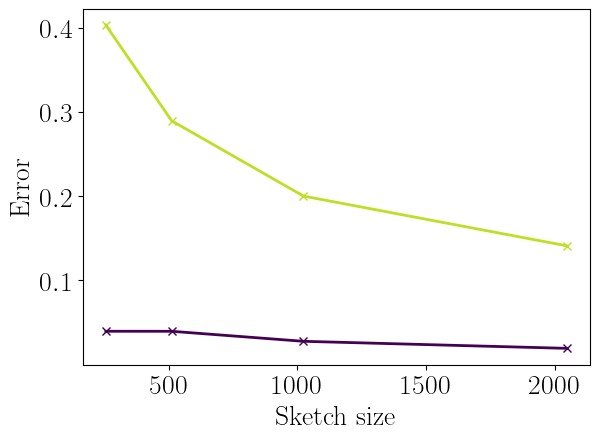

In [3]:
errors1 = test_sketchers([PS, SimpleJL],
                           [256, 512, 1024, 2048], 100, vec_of_vecs, queries, [ 'PS', 'JL'], "Zipfian Distribution")

In [4]:
def random_rotate_exact(x):
    """Exactly rotates a vector x using a dense random orthogonal matrix."""
    n = len(x)
    
    # 1. Generate a random matrix with standard normal entries
    A = np.random.randn(n, n)
    
    # 2. Compute the QR decomposition
    Q, R = np.linalg.qr(A)
    
    # 3. Make the distribution uniform (Haar measure)
    # The diagonal of R might have negative signs, which biases the distribution.
    # We multiply the columns of Q by the sign of the diagonal of R.
    d = np.diagonal(R)
    phases = d / np.abs(d)
    Q_uniform = Q * phases
    
    # 4. Apply the rotation
    return Q_uniform @ x

random_rotator = JL(1000, 1)

synt_vecs = []
queries = []
rng = np.random.default_rng(seed=1)

for i in range(0, 10):
    synt_vecs.append(random_rotator.sketch(rng.zipf(a=2, size=1000)).sk_values)
    queries.append(random_rotator.sketch(rng.zipf(a=2, size=1000)).sk_values)

vec_of_vecs = [synt_vecs for i in range(0, 10)]

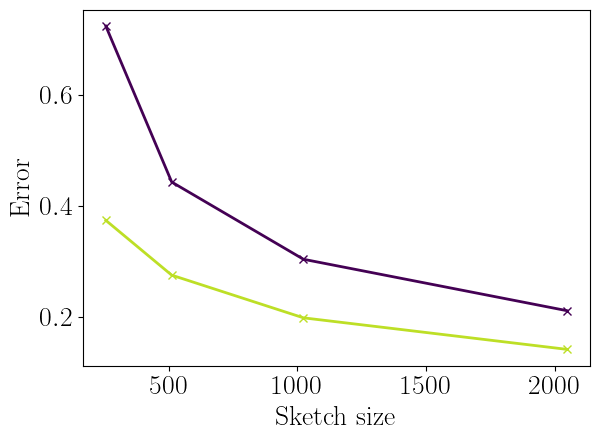

In [5]:
errors2 = test_sketchers([PS, SimpleJL],
                           [256, 512, 1024, 2048], 100, vec_of_vecs, queries, [ 'PS', 'JL'], "Zipfian Distribution after random rotation")

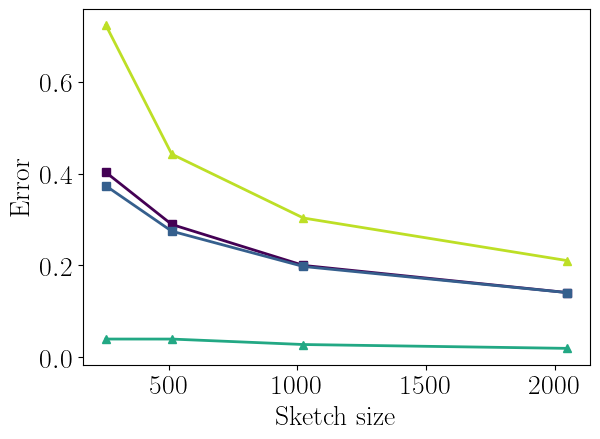

In [ ]:
import matplotlib.pyplot as plt
errors = [errors1[1], errors2[1], errors1[0], errors2[0]]


colors = plt.cm.viridis(np.linspace(0, 0.9, len(errors)))
colors = [colors[1], colors[0], colors[2], colors[3]]

markers = ['s', 's', '^', '^']
list_sizes = [256, 512, 1024, 2048]
title = 'Zipfian Distribution'
#list_names = ['SimHash', 'Johnson-Lindenstrauss','Priority Sampling Quantized', 'Priority Sampling']
list_names = ["Johnson-Lindenstrauss", "Johnson-Lindenstrauss after rotation", "Priority Sampling", "Priority Sampling after rotation"]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times Roman"],
    "font.size": 20
})



if markers is None:
    markers = ['x' for i in range(0, len(errors))]

for i in range(0, len(errors)):
    plt.plot(list_sizes, errors[i], marker=markers[i], color=colors[i], label=list_names[i], linewidth=2)


#plt.title()
plt.xlabel("Sketch size")
plt.ylabel("Error")
#plt.ylim(0, 0.1)
#plt.legend()
plt.grid(False)
plt.tight_layout()

handles, labels = plt.gca().get_legend_handles_labels()

plt.savefig("figs/" + title + ".pdf", format="pdf", bbox_inches='tight')
# Show the plot
plt.show()
plt.close()

fig_leg = plt.figure(figsize=(3,1))
fig_leg.legend(handles=handles, labels=labels, loc='center', ncol=len(handles) // 2)
plt.savefig("figs/" + title + "_legend.pdf", format="pdf", bbox_inches='tight')
plt.close()


In [9]:
import numpy as np
from scipy.sparse import coo_array


synt_vecs = []
queries = []
rng = np.random.default_rng(seed=1)

for i in range(0, 10):
    synt_vecs.append(rng.zipf(a=2, size=1000))
    queries.append(rng.zipf(a=2, size=1000))

vec_of_vecs = [synt_vecs for i in range(0, 10)]


In [4]:
class SimpleASaS:
    def __init__(self, size, seed):
        self.sketcher = ASaS(size, seed, SH, dim=1000)

    def sketch(self, vec):
        return self.sketcher.sketch(vec)

    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    
    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleSepareteAndSketch50:
    def __init__(self, size, seed):
        self.sketcher = SaS(int(0.5 * size), int(0.5 * size), seed, SH, dim=1000)
    def sketch(self, vec):
        return self.sketcher.sketch(vec)
    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)    
    def get_matrix(self):
        return self.sketcher.get_matrix()
    
class SimpleSH:
    def __init__(self, size, seed):
        self.sketcher = SH(size, seed, dim=1000)
    def sketch(self, vec):
        return self.sketcher.sketch(vec)
    def sketch_asym(self, vec):
        return self.sketcher.sketch_asym(vec)
    def get_matrix(self):
        return self.sketcher.get_matrix()


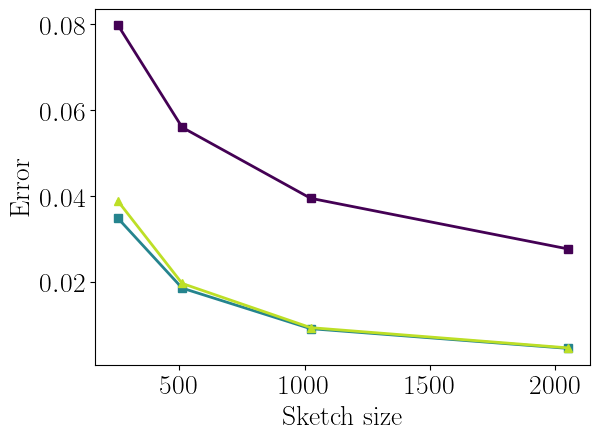

[[0.07980906007939526,
  0.05599716338265589,
  0.03947512766424733,
  0.027697949950871947],
 [0.03481961689226752,
  0.01854336249839232,
  0.009098643234753342,
  0.004511681387676323],
 [0.03880572382113121,
  0.01962832042822964,
  0.009338761692891868,
  0.004634381291368836]]

In [5]:
test_sketchers([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048], 100, vec_of_vecs, queries, ['SimHash', 'Adaptive Select and Sketch', 'Separate and sketch 50/50 Split',], "ASAS Zipfian Distribution", markers=["s", "s", "^"])

In [9]:
synt_vecs = []
queries = []
rng = np.random.default_rng(seed=1)

for i in range(0, 10):
    synt_vecs.append(rng.uniform(low=0, high=1, size=1000))
    queries.append(rng.uniform(low=0, high=1, size=1000))

vec_of_vecs = [synt_vecs for i in range(0, 10)]


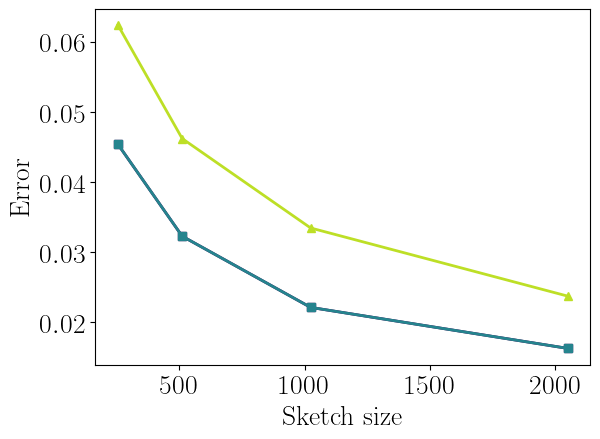

[[0.045372802406029464,
  0.03226383277483882,
  0.022107407662686995,
  0.016259882676721293],
 [0.045372802406029464,
  0.03226383277483882,
  0.022107407662686995,
  0.016259882676721293],
 [0.06238032473176005,
  0.04619859674793553,
  0.03343894289466757,
  0.023721288340414464]]

In [10]:
test_sketchers([SimpleSH, SimpleASaS, SimpleSepareteAndSketch50],
                           [256, 512, 1024, 2048], 100, vec_of_vecs, queries, ['SimHash', 'Adaptive Select and Sketch', 'Separate and sketch 50/50 Split',], "ASAS Uniform Distribution", markers=["s", "s", "^"])